### Loading Required packages 

In [2]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\UserIBM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Data Loading

In [7]:
### Loading pakistani political parties tweet dataset
pmln = pd.read_csv("C:/Users/UserIBM/Documents/Enischyo Intership/PMLN_tweets.csv")
ppp = pd.read_csv("C:/Users/UserIBM/Documents/Enischyo Intership/PPP_tweets.csv")
pti = pd.read_csv("C:/Users/UserIBM/Documents/Enischyo Intership/PTI_tweets.csv")


In [8]:
### Merging the datasets by adding party column 
pti["Party"] = "PTI"
pmln["Party"] = "PMLN"
ppp["Party"] = "PPP"
df = pd.concat([pti, pmln, ppp], ignore_index=True)

In [9]:
print(df.shape)

(1307966, 4)


In [10]:
df.head()

,preprocessed_tweet,language,labels,Party
0,sue,en,0,PTI
1,Northern Areas Pakistan,en,0,PTI
2,opinion officials tweet representatives commen...,en,0,PTI
3,Tweet account point agenda Reform Control Prov...,en,0,PTI
4,Punjab province Federal PTI suppertes hv Inter...,en,1,PTI


In [19]:
df.tail()

,preprocessed_tweet,language,labels,Party
1307960,lanjutkan bersama ishak yudha sumsel lebih gem...,in,0,PPP
1307961,jelang pilkada ppp siapkan kader muda,in,0,PPP
1307962,ppp sumut tuntut ketum romi mundur karena dukung,in,0,PPP
1307964,sikap amp idiologi politik yg dititipkan alm g...,in,0,PPP
1307965,kepada yth vidio ini mengandung amp mendiskrim...,in,0,PPP


In [11]:
df.columns

Index(['preprocessed_tweet', 'language', 'labels', 'Party'], dtype='str')

### Data Cleaning 

In [21]:
### missing values 
df.isnull().sum()

preprocessed_tweet     0
language              16
labels                 0
Party                  0
dtype: int64

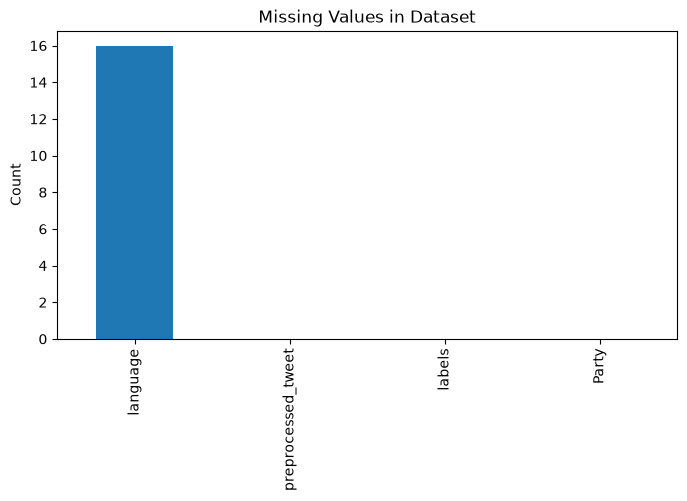

In [27]:
### visualizing missing 
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
missing.plot(kind='bar')
plt.title("Missing Values in Dataset")
plt.ylabel("Count")
plt.show()

In [9]:
### removing missing value rows 
df = df.dropna(subset=["language"])

In [36]:
#### verifying after removing rows 
df.isnull().sum()

preprocessed_tweet    0
language              0
labels                0
Party                 0
dtype: int64

In [37]:
### duplicate rows 
df.duplicated().sum()

np.int64(0)

In [25]:
### checking for empty tweets 
(df["preprocessed_tweet"]=="").sum()

np.int64(0)

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 1029043 entries, 0 to 1307965
Data columns (total 4 columns):
 #   Column              Non-Null Count    Dtype
---  ------              --------------    -----
 0   preprocessed_tweet  1029043 non-null  str  
 1   language            1029043 non-null  str  
 2   labels              1029043 non-null  int64
 3   Party               1029043 non-null  str  
dtypes: int64(1), str(3)
memory usage: 39.3 MB


In [39]:
df.dtypes

preprocessed_tweet      str
language                str
labels                int64
Party                   str
dtype: object

### Exploratory Data Analysis (EDA)

In [40]:
## checking language distribution
df['language'].value_counts()

language
en    546133
ur    380522
in    102388
Name: count, dtype: int64

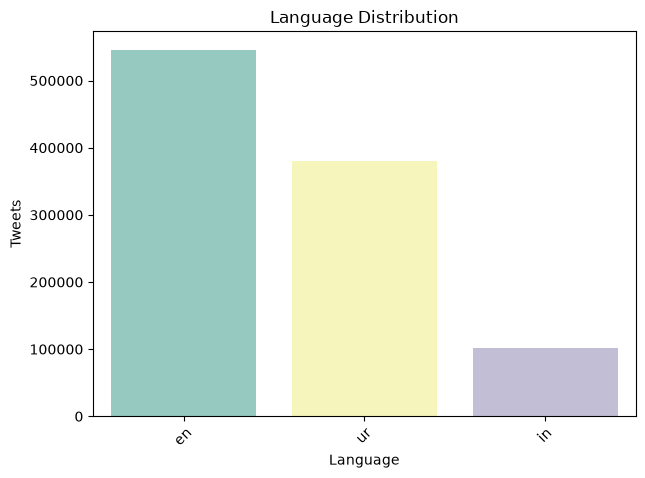

In [45]:
### visualizing language distribution 
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="language",
    order=df["language"].value_counts().index,
    palette="Set3"
)

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Tweets")

plt.xticks(rotation=45)

plt.show()

In [41]:
## Checking party distribution 
df['Party'].value_counts()

Party
PTI     548064
PMLN    370899
PPP     110080
Name: count, dtype: int64

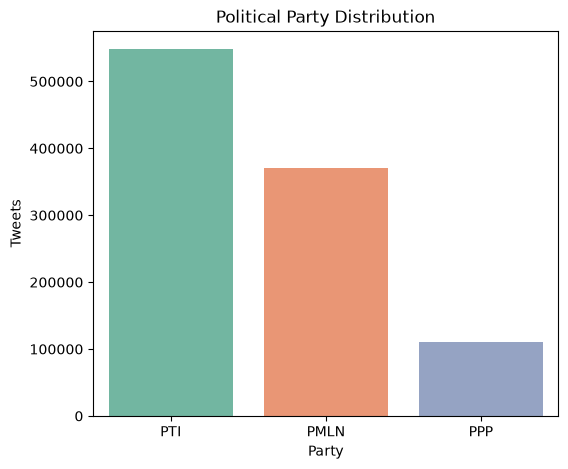

In [44]:
### visualizing party distribution 
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Party",
    palette="Set2"
)

plt.title("Political Party Distribution")
plt.xlabel("Party")
plt.ylabel("Tweets")
plt.show()

In [42]:
### check label distribution (0 is positive & 1 is negative label)
df["labels"].value_counts()

labels
0    566839
1    462204
Name: count, dtype: int64

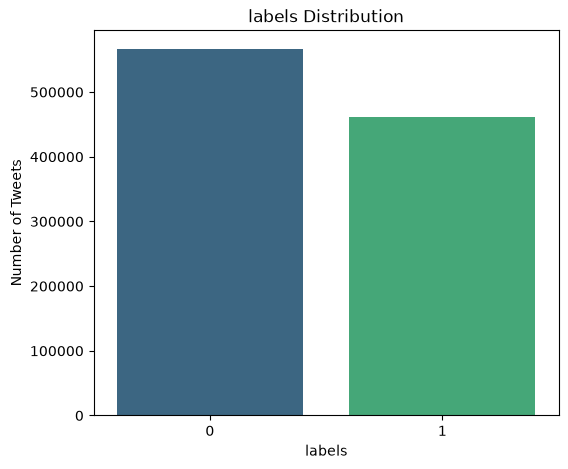

In [43]:
#### visualizing label distribution 
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="labels",
    palette="viridis"
)

plt.title("labels Distribution")
plt.xlabel("labels")
plt.ylabel("Number of Tweets")
plt.show()

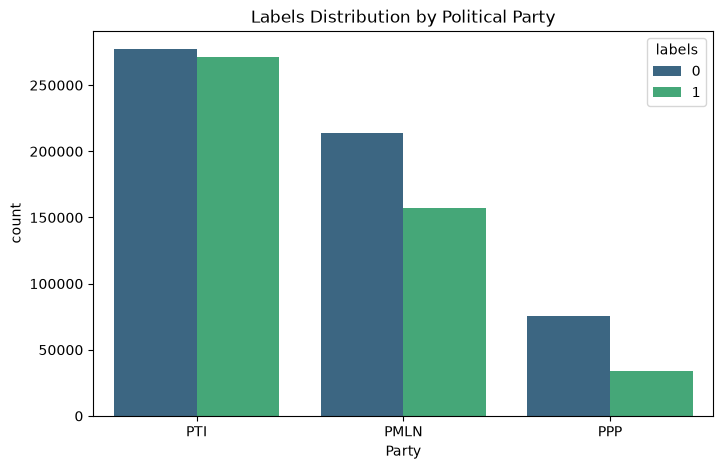

In [47]:
### label distribution by party 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Party",
    hue="labels",
    palette="viridis"
)

plt.title("Labels Distribution by Political Party")

plt.show()

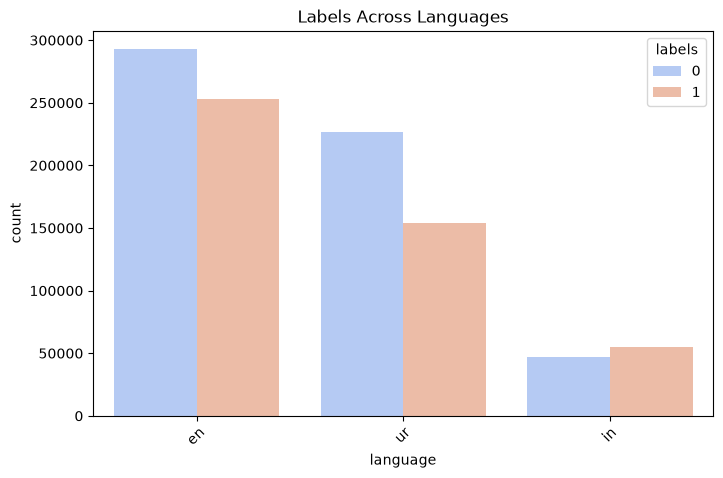

In [49]:
#### visualizing labels by language 
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="language",
    hue="labels",
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Labels Across Languages")

plt.show()

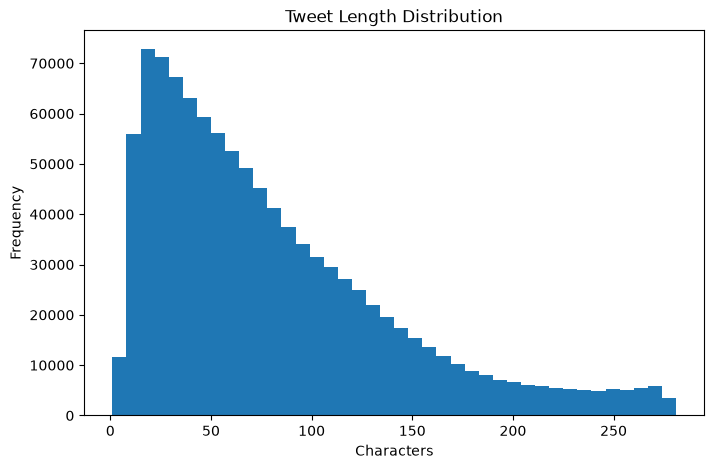

In [51]:
### visualizing tweet length
df["tweet_length"] = df["preprocessed_tweet"].apply(len)
plt.figure(figsize=(8,5))
plt.hist(
    df["tweet_length"],
    bins=40
)
plt.title("Tweet Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

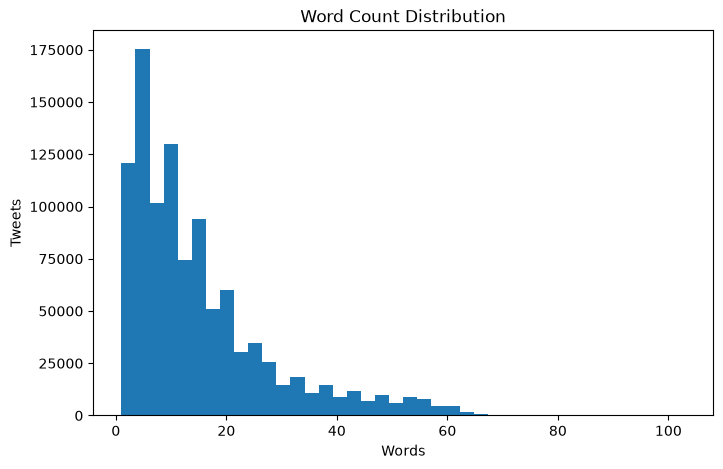

In [52]:
### visualizing word count 
df["word_count"] = df["preprocessed_tweet"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
plt.hist(
    df["word_count"],
    bins=40
)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Tweets")
plt.show()

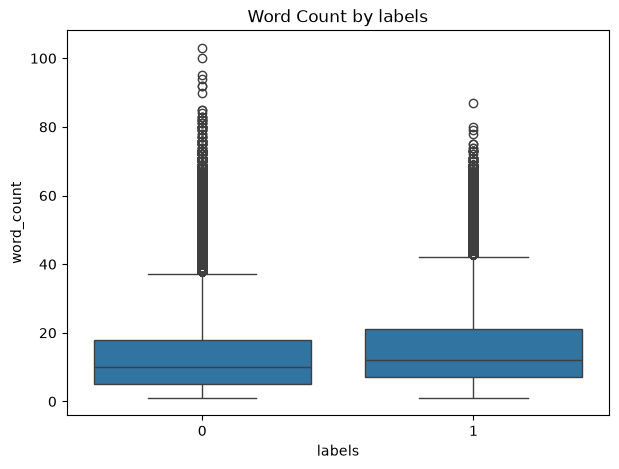

In [53]:
### word count by labels 
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="labels",
    y="word_count"
)
plt.title("Word Count by labels")
plt.show()

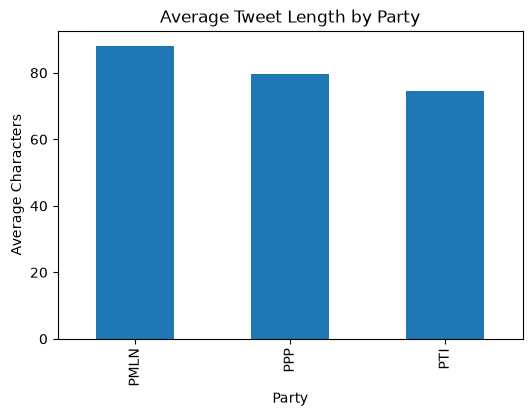

In [54]:
### average tweet length by party 
df.groupby("Party")["tweet_length"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Average Characters")

plt.title("Average Tweet Length by Party")

plt.show()

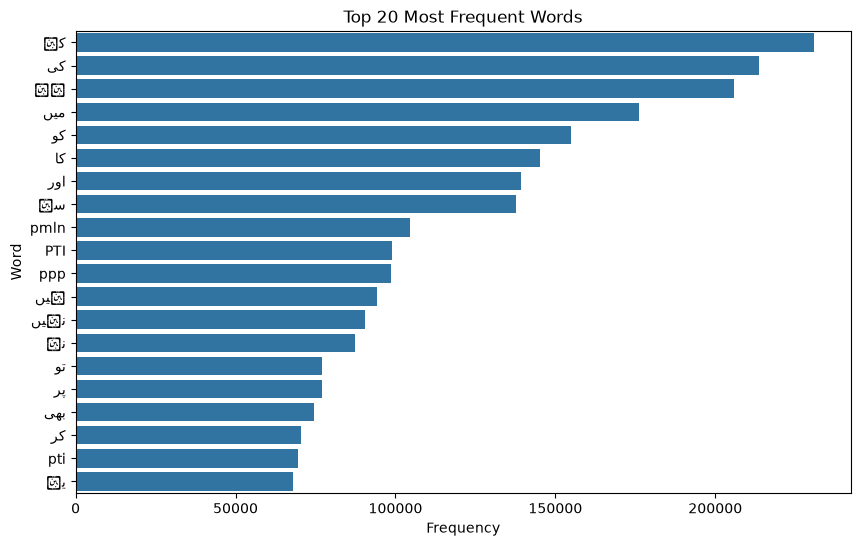

In [56]:
### most frequent words 
from collections import Counter
all_words = " ".join(df["preprocessed_tweet"])
words = all_words.split()
common = Counter(words).most_common(20)
common_df = pd.DataFrame(common, columns=["Word","Frequency"])
common_df
plt.figure(figsize=(10,6))
sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word"
)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [58]:
#### installing word Cloud package 
!pip install wordcloud

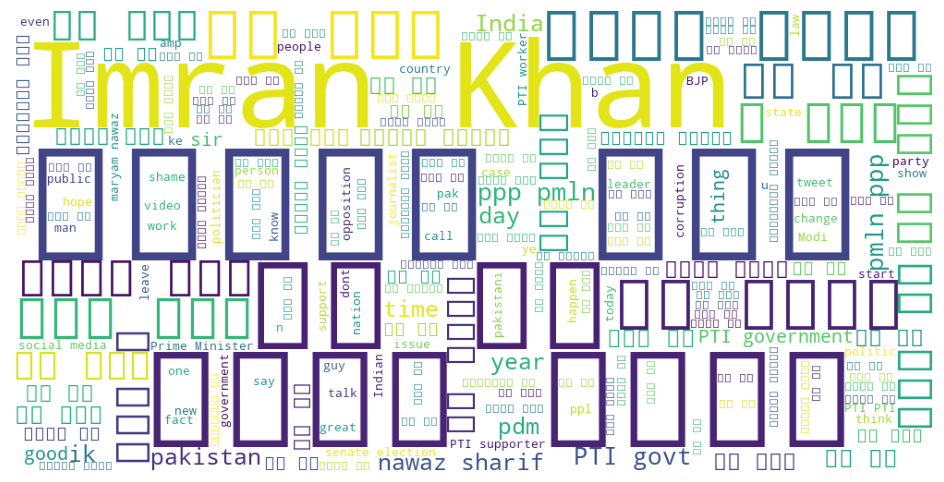

In [59]:
### word cloud 
from wordcloud import WordCloud
text = " ".join(df["preprocessed_tweet"])
wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)
plt.figure(figsize=(14,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

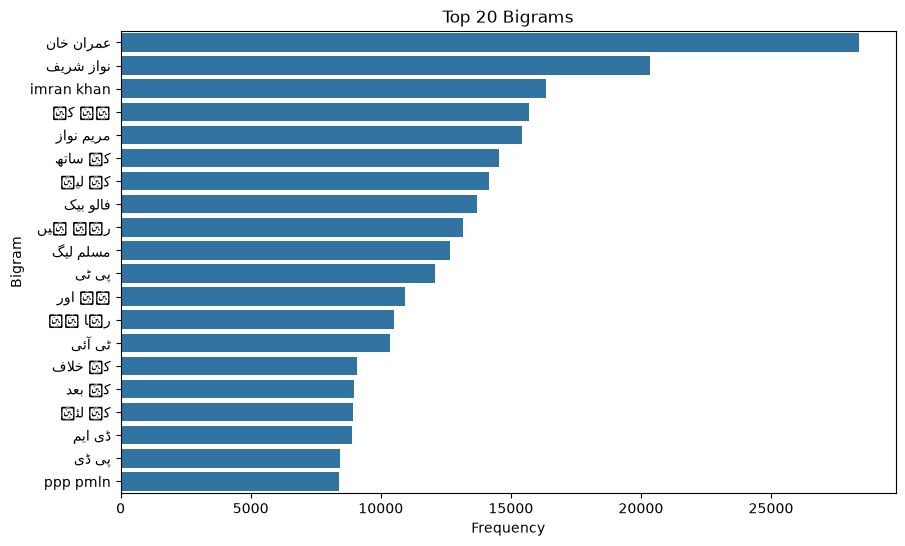

In [28]:
### top 20 Bigrams 
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(2,2), max_features=20)
X = cv.fit_transform(df["preprocessed_tweet"])
sum_words = X.sum(axis=0)
words_freq = [
    (word, sum_words[0, idx])
    for word, idx in cv.vocabulary_.items()
]
bigram = pd.DataFrame(
    words_freq,
    columns=["Bigram","Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
)
bigram
plt.figure(figsize=(10,6))
sns.barplot(
    data=bigram,
    x="Frequency",
    y="Bigram"
)
plt.title("Top 20 Bigrams")
plt.show()

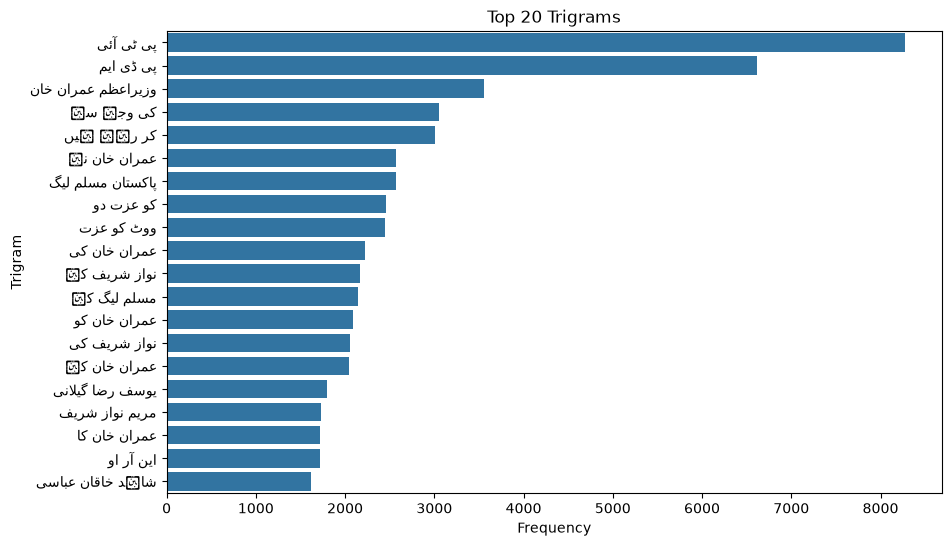

In [62]:
### Top Trigrams
cv = CountVectorizer(
    ngram_range=(3,3),
    max_features=20
)
X = cv.fit_transform(df["preprocessed_tweet"])
sum_words = X.sum(axis=0)
words_freq = [
    (word, sum_words[0, idx])
    for word, idx in cv.vocabulary_.items()
]
trigram = pd.DataFrame(
    words_freq,
    columns=["Trigram","Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=trigram,
    x="Frequency",
    y="Trigram"
)
plt.title("Top 20 Trigrams")

plt.show()

#### Feature Engineering 

In [29]:
### Define Features and Target
X = df["preprocessed_tweet"]
y = df["labels"]

In [30]:
### Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1030524
Testing samples: 257632


In [31]:
#### TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.90
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (1030524, 5000)
Testing TF-IDF Shape: (257632, 5000)


In [32]:
### chekcking vocabulary size 
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


In [33]:
#### Display First 20 Features
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['aa' 'aaj' 'aap' 'abbasi' 'abdul' 'abhi' 'absolutely' 'abt' 'abuse'
 'accept' 'according' 'account' 'account suspended' 'accountability'
 'accuse' 'achieve' 'act' 'action' 'active' 'activist']


In [34]:
#### Save the TF-IDF Vectorizer Flask deployment
import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

### Model Training 

In [35]:
### loading libraries for model training 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [36]:
### creating ML Models
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Linear SVC":
        LinearSVC(
            random_state=42
        ),

    "Multinomial Naive Bayes":
        MultinomialNB(),

    "SGD Classifier":
        SGDClassifier(
            random_state=42
        )
}

In [37]:
### Train & Evaluate Every Model
results = []

trained_models = {}

predictions = {}

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    trained_models[name] = model

    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    151024
           1       0.87      0.84      0.85    106608

    accuracy                           0.88    257632
   macro avg       0.88      0.87      0.88    257632
weighted avg       0.88      0.88      0.88    257632

Linear SVC
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    151024
           1       0.87      0.84      0.85    106608

    accuracy                           0.88    257632
   macro avg       0.88      0.87      0.88    257632
weighted avg       0.88      0.88      0.88    257632

Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.83      0.86      0.84    151024
           1       0.79      0.76      0.77    106608

    accuracy                           0.82    257632
   macro avg       0.81      0.81      0.81    257632
weighted avg       

### Model Comparison

In [38]:
### Comparing results 
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.879662,0.868463,0.835772,0.851804
1,Linear SVC,0.879526,0.867744,0.836326,0.851745
2,SGD Classifier,0.844701,0.866301,0.738706,0.797432
3,Multinomial Naive Bayes,0.815229,0.788790,0.755872,0.771980


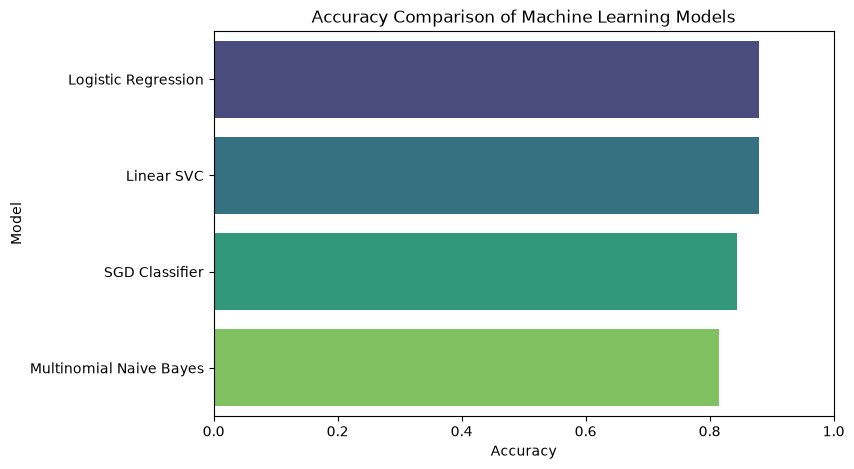

In [39]:
### Visualize Model Performance (Accuracy comparison)
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlim(0,1)
plt.show()

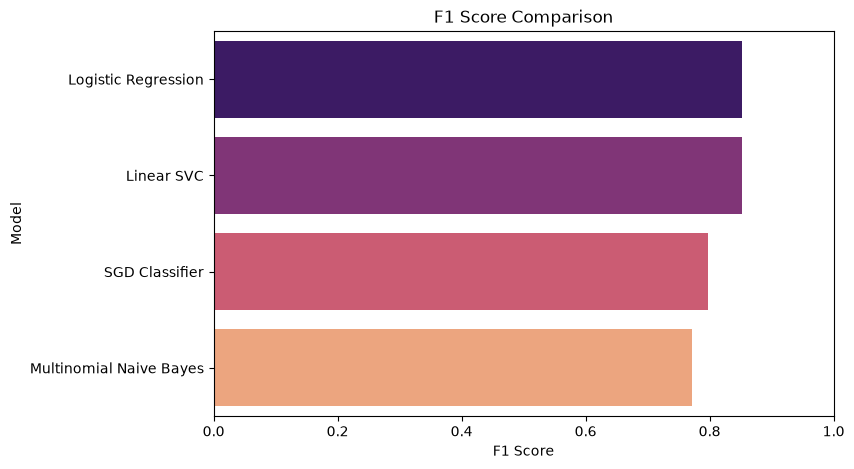

In [40]:
### Visualize Model Performance (F1-Score comparison)
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model",
    palette="magma"
)
plt.title("F1 Score Comparison")
plt.xlim(0,1)
plt.show()

#### Best Model Selection

In [41]:
#### Select the Best Model
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [42]:
best_model = trained_models[best_model_name]

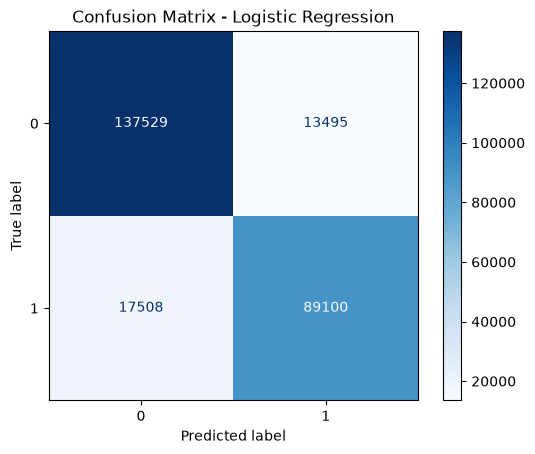

In [43]:
### Confusion Matrix of the best model 
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = predictions[best_model_name]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [44]:
### Save the Best Model
import joblib
joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

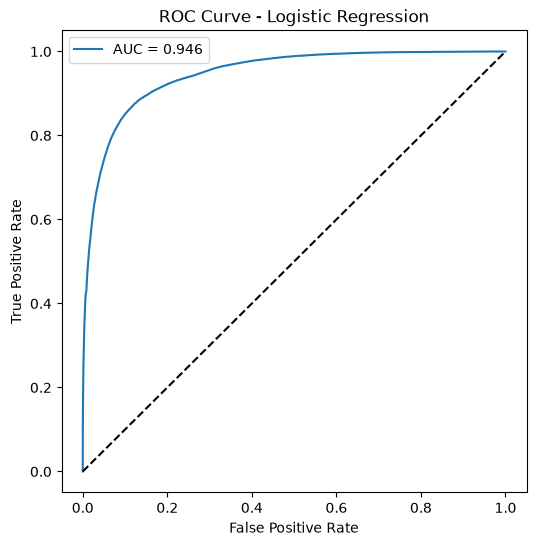

In [45]:
### ROC Curve
from sklearn.metrics import roc_curve, auc
if hasattr(best_model, "predict_proba"):
    y_scores = best_model.predict_proba(X_test_tfidf)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores = best_model.decision_function(X_test_tfidf)
else:
    y_scores = None
if y_scores is not None:
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {best_model_name}")
    plt.legend()
    plt.show()

### Best Model Hyperparameter Tunning 

In [46]:
### Tunning Hyperparameters of the best model 
from sklearn.model_selection import GridSearchCV
### define parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}
### Run GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`t

In [47]:
### best parameters
print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross Validation F1:")
print(grid.best_score_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross Validation F1:
0.852764079311723


In [48]:
### best model 
best_lr = grid.best_estimator_

In [49]:
### predictions
y_pred_best = best_lr.predict(X_test_tfidf)

In [50]:
### Final Evaluation after tuning hyperparameters
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.8804923301453236
Precision: 0.8678569695793509
Recall   : 0.8389332883085697
F1 Score : 0.8531500550884038

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.91      0.90    151024
           1       0.87      0.84      0.85    106608

    accuracy                           0.88    257632
   macro avg       0.88      0.87      0.88    257632
weighted avg       0.88      0.88      0.88    257632



In [59]:
### save the final model 
import joblib
joblib.dump(best_lr, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

### Model Deployment (Flask API)

In [53]:
!pip install flask

In [4]:
### Model Deployment Flask API
from flask import Flask, request, jsonify
import joblib
import pandas as pd

# Initialize Flask app
app = Flask(__name__)
# Load saved sentiment model and vectorizer
model = joblib.load("best_sentiment_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")
@app.route("/")
def home():
    return "Sentiment Analysis API is Running"
@app.route("/predict", methods=["POST"])
def predict():

    try:
        # Get JSON input
        data = request.get_json()
        # Extract text
        text = data["text"]
        # Convert text into TF-IDF features
        text_tfidf = tfidf.transform([text])
        # Predict sentiment
        prediction = model.predict(text_tfidf)
        # Confidence score
        if hasattr(model, "predict_proba"):
            confidence = max(model.predict_proba(text_tfidf)[0])
        else:
            confidence = None
        response = {
            "sentiment": str(prediction[0]),
            "confidence": round(float(confidence), 4) 
            if confidence else "Not Available"
        }
        return jsonify(response)
    except Exception as e:
        return jsonify({
            "error": str(e)
        })

if __name__ == "__main__":
    app.run(debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [28/Jul/2026 23:43:19] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [28/Jul/2026 23:43:22] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [28/Jul/2026 23:43:23] "GET / HTTP/1.1" 200 -


### Model Deployment (Flask API)

In [5]:
### predict endpoint 
import requests

url = "http://127.0.0.1:5000/predict"

data = {
    "text": "I really loved this movie. It was amazing!"
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'confidence': 0.9643, 'sentiment': '0'}


### Web Inferface (Testing)

In [4]:
### testing the web interface of PythonAnywhere 
import requests

url = "https://DataInsightsbyAS.pythonanywhere.com/predict"

data = {
    "text": "PTI supporters celebrated the successful rally."
}

response = requests.post(
    url,
    json=data,
    headers={"Content-Type": "application/json"}
)

print(response.status_code)
print(response.text)

200
{"confidence":0.9746,"sentiment":"0"}



In [5]:
import requests

url = "https://DataInsightsbyAS.pythonanywhere.com/predict"

data = {
    "text": "I hate this product. It is the worst thing I have ever bought."
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'confidence': 0.9967, 'sentiment': '1'}


In [6]:
### testing the web interface of PythonAnywhere (encoded 0 as positive and 1 as negative)
import requests

url = "https://DataInsightsbyAS.pythonanywhere.com/predict"

data = {
    "text": "PTI supporters celebrated the successful rally."
}

response = requests.post(
    url,
    json=data,
    headers={"Content-Type": "application/json"}
)

print(response.status_code)
print(response.text)

200
{"confidence":0.9746,"sentiment":"Positive"}



In [7]:
import requests

url = "https://DataInsightsbyAS.pythonanywhere.com/predict"

data = {
    "text": "I hate this product. It is the worst thing I have ever bought."
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'confidence': 0.9967, 'sentiment': 'Negative'}
